Raw images from Yalour and Green islands firstly were splitted into train and validation datasets but lated I merged them into one train dataset named yalour_green

In [1]:
import shutil
import random
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [2]:
random.seed(42)

In [ ]:
dataset1 = Path("data/raw_data/images3")
dataset2 = Path("data/raw_data/yalyr1")
dataset3 = Path("data/raw_data/yalyr2")
dataset4 = Path("data/raw_data/yalyr3")

In [ ]:
output_dir = Path("data/raw_dataset")

In [5]:
images_dir = output_dir / "images"
labels_dir = output_dir / "labels"

In [6]:
(images_dir / "train").mkdir(parents=True, exist_ok=True)
(images_dir / "val").mkdir(parents=True, exist_ok=True)
(labels_dir / "train").mkdir(parents=True, exist_ok=True)
(labels_dir / "val").mkdir(parents=True, exist_ok=True)

In [7]:
all_images = []

for dataset in [dataset1, dataset2, dataset3, dataset4]:
    imgs = list((dataset / "images").glob("*"))
    all_images.extend(imgs)

print(f"Total images found: {len(all_images)}")

Total images found: 500


In [8]:
random.shuffle(all_images)

split_ratio = 0.8
split_index = int(len(all_images) * split_ratio)

train_images = all_images[:split_index]
val_images = all_images[split_index:]

print(f"Train: {len(train_images)}")
print(f"Val: {len(val_images)}")

Train: 400
Val: 100


In [9]:
def copy_files(image_list, split):
    for img_path in image_list:
        label_path = img_path.parent.parent / "labels" / (img_path.stem + ".txt")
        
        if not label_path.exists():
            print(f"Missing label for {img_path.name}")
            continue
        
        shutil.copy(img_path, images_dir / split / img_path.name)
        shutil.copy(label_path, labels_dir / split / label_path.name)

copy_files(train_images, "train")
copy_files(val_images, "val")

print("Dataset prepared.")

Dataset prepared.


In [10]:
yaml_content = f"""
path: {output_dir.resolve()}

train: images/train
val: images/val

names:
  0: Penguine
"""

with open(output_dir / "penguins.yaml", "w") as f:
    f.write(yaml_content)

print("penguins.yaml created.")


penguins.yaml created.


In [11]:
def show_sample(image_path):
    label_path = output_dir / "labels" / image_path.parent.name / (image_path.stem + ".txt")
    
    img = cv2.imread(str(image_path))
    h, w, _ = img.shape
    
    with open(label_path, "r") as f:
        lines = f.readlines()
    
    for line in lines:
        cls, x, y, bw, bh = map(float, line.strip().split())
        
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)
        
        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
    
    plt.figure(figsize=(8,8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


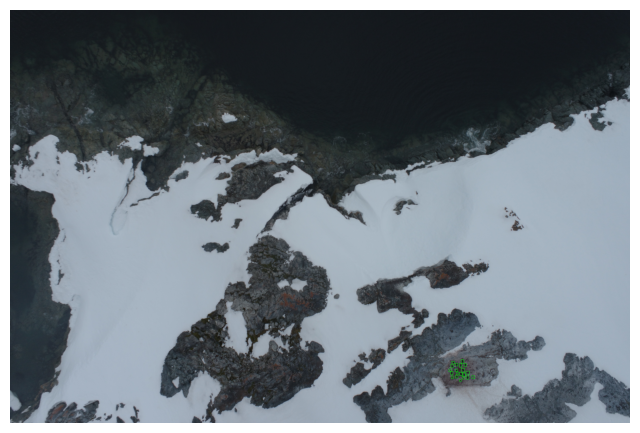

In [14]:
sample_img = list((images_dir / "train").glob("*"))[222]
show_sample(sample_img)

In [15]:
def analyze_penguin_distribution(dataset_path):
    results = {}

    for split in ["train", "val"]:
        labels_path = dataset_path / "labels" / split
        
        total_images = 0
        images_with_penguins = 0
        images_without_penguins = 0
        total_penguins = 0
        
        for label_file in labels_path.glob("*.txt"):
            total_images += 1
            
            with open(label_file, "r") as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
            
            if len(lines) > 0:
                images_with_penguins += 1
                total_penguins += len(lines)
            else:
                images_without_penguins += 1
        
        results[split] = {
            "total_images": total_images,
            "images_with_penguins": images_with_penguins,
            "images_without_penguins": images_without_penguins,
            "total_penguins": total_penguins
        }
    
    return results


In [16]:
stats = analyze_penguin_distribution(output_dir)

for split, data in stats.items():
    print(f"\n=== {split.upper()} ===")
    print(f"Total images: {data['total_images']}")
    print(f"Images with penguins: {data['images_with_penguins']}")
    print(f"Images without penguins: {data['images_without_penguins']}")
    print(f"Total penguins annotated: {data['total_penguins']}")


=== TRAIN ===
Total images: 400
Images with penguins: 166
Images without penguins: 234
Total penguins annotated: 10567

=== VAL ===
Total images: 100
Images with penguins: 45
Images without penguins: 55
Total penguins annotated: 3060


In [17]:
def analyze_bbox_sizes(dataset_path):
    widths = []
    heights = []

    for split in ["train", "val"]:
        labels_path = dataset_path / "labels" / split
        
        for label_file in labels_path.glob("*.txt"):
            with open(label_file, "r") as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
            
            for line in lines:
                values = list(map(float, line.split()))
                _, x, y, w, h = values
                widths.append(w)
                heights.append(h)

    print("Average width:", np.mean(widths))
    print("Average height:", np.mean(heights))
    print("Min width:", np.min(widths))
    print("Min height:", np.min(heights))
    print("Max width:", np.max(widths))
    print("Max height:", np.max(heights))

In [18]:
analyze_bbox_sizes(output_dir)

Average width: 0.0053704342514399525
Average height: 0.008252182141447134
Min width: 0.0006757842031866801
Min height: 0.00045052280212438234
Max width: 0.05220093367932007
Max height: 0.08935006439589147
